In [1]:
#Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
  # Hiển thị 5 hàng đầu của dữ liệu
df = pd.read_csv('/kaggle/input/datasets/ngyyenhon/xsscas/credit_card_transactions.csv')
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [4]:
# Kiểm tra số lượng và kiểu dữ liệu của dữ liệu
print(df.shape)       # (số_dòng, số_cột)
print(df.shape[0])    # số dòng
print(df.shape[1])    # số cột

print(df.info())      # thông tin toàn bộ DataFrame

(1296675, 24)
1296675
24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float6

In [5]:
# Sử dụng hàm describe() để thống kê dữ liệu
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.100702e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.682575e+04
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.001000e+03
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,2.511400e+04
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.586000e+04
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.940300e+04


In [6]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

####1. trans_date_trans_time: thời gian thực hiện giao dịch
####2. cc_num: mã định danh thẻ tín dụng của khách hàng
####3. merchant: tên người bàn hàng
####4. category: loại hình kinh doanh
####5. amt: số tiền giao dịch
####6. first: tên riêng của khách hàng
####7. last: họ của khách hàng
####8. gender: giới tính của khách hàng
####9. street: địa chỉ nhà của khách hàng
####10. state: bang nơi khách hàng lưu trú
####11. zip: mã bưu điện nơi khách hàng lưu trú
####12. lat: vĩ độ của địa chỉ nhà khách hàng
####13. long: kinh độ của địa chỉ nhà khách hàng
####14. city_pop: dân số thành phố nơi khách hàng lưu trú
####15. job: nghề nghiệp của khách
####16. dob: ngày sinh của khách  
####17. trans_num: số định danh của giao dịch
####18. unix_time: thời gian giao dịch được ghi nhận dưới dạng dấu thời gian Unix
####19. merch_lat: vĩ độ của giao dịch
####20. merch_long: kinh độ của giao dịch
####21. is_fraud: giao dịch có phải gian lận hay không
####22. merch_zipcode: mã bưu điện nơi diễn ra giao dịch

In [7]:
df.isna().sum()


Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64

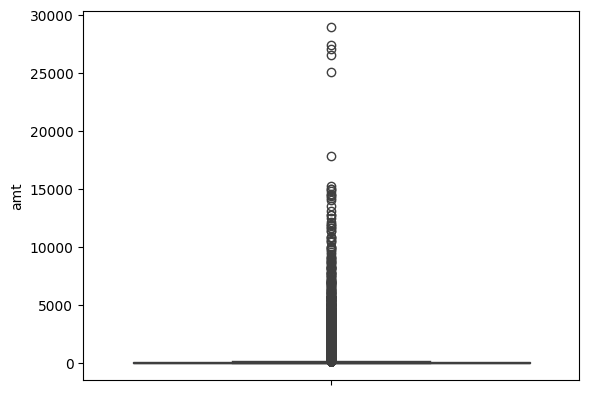

In [8]:
sns.boxplot(df["amt"])
plt.show()

In [9]:
q1 = df["amt"].quantile(0.25)
q3 = df["amt"].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print("q1 : ", q1)
print("q3 : ", q3)
print("IQR : ", IQR)
print("lower_bound : ", lower_bound)
print("upper_bound : ", upper_bound)

q1 :  9.65
q3 :  83.14
IQR :  73.49
lower_bound :  -100.58499999999998
upper_bound :  193.375


In [10]:
df.drop(columns=['merch_zipcode'], inplace=True)

In [11]:
print("Tổng missing còn lại:", df.isnull().sum().sum())

Tổng missing còn lại: 0


/tmp/ipykernel_57/1623951553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_fraud', data=df, palette='viridis')


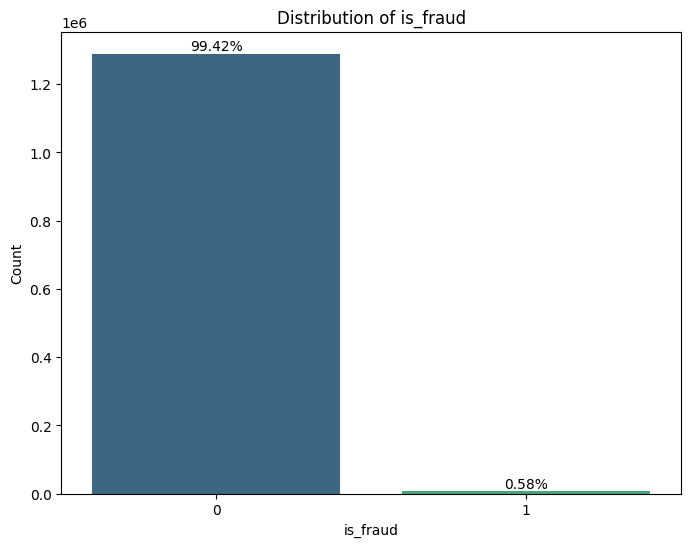

In [12]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='is_fraud', data=df, palette='viridis')

total = len(df)

# Gắn % lên mỗi cột
for p in ax.patches:
    percent = 100 * p.get_height() / total
    ax.annotate(f'{percent:.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Distribution of is_fraud')
plt.ylabel('Count')
plt.show()

##**Dữ liệu thời gian**

In [13]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['month'] = df['trans_date_trans_time'].dt.to_period('M')
df['season'] = df['trans_date_trans_time'].dt.month % 12 // 3 + 1
df['year'] = df['trans_date_trans_time'].dt.year
df['year_season'] = (
    df['year'].astype(str) + ' - ' +
    df['season'].map({1:'Winter',2:'Spring',3:'Summer',4:'Autumn'})
)

/tmp/ipykernel_57/543903627.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


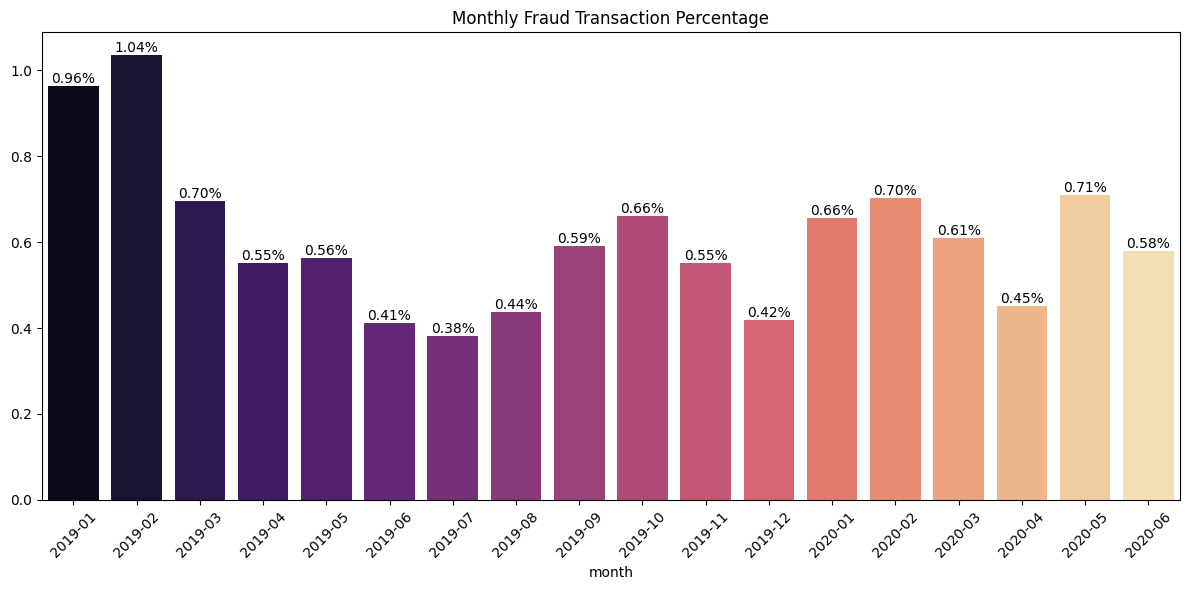

In [14]:
monthly_total = df.groupby('month').size()
monthly_fraud = df[df['is_fraud']==1].groupby('month').size()
monthly_fraud_percent = (monthly_fraud / monthly_total) * 100

plt.figure(figsize=(12,6))
sns.barplot(
    x=monthly_fraud_percent.index.astype(str),
    y=monthly_fraud_percent.values,
    palette="magma"
)

plt.title('Monthly Fraud Transaction Percentage')
plt.xticks(rotation=45)

for i, v in enumerate(monthly_fraud_percent.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

##**Đầu năm 2019 tỷ lệ gian lận cao hơn đầu năm 2020**

/tmp/ipykernel_57/3683168200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_fraud_percent.index,


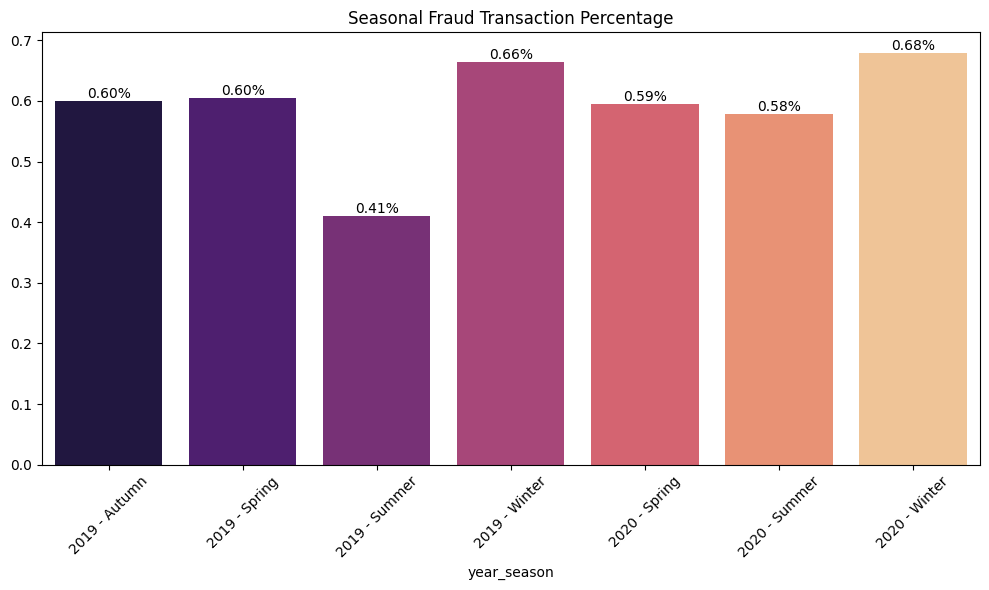

In [15]:
season_total = df.groupby('year_season').size()
season_fraud = df[df['is_fraud']==1].groupby('year_season').size()
season_fraud_percent = (season_fraud / season_total) * 100

plt.figure(figsize=(10,6))
sns.barplot(x=season_fraud_percent.index,
            y=season_fraud_percent.values,
            palette="magma")

plt.xticks(rotation=45)
plt.title('Seasonal Fraud Transaction Percentage')

for i, v in enumerate(season_fraud_percent.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

##**Các tháng mùa đông có tỷ lệ gian lận cao hơn các mùa khác**

/tmp/ipykernel_57/3541605269.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


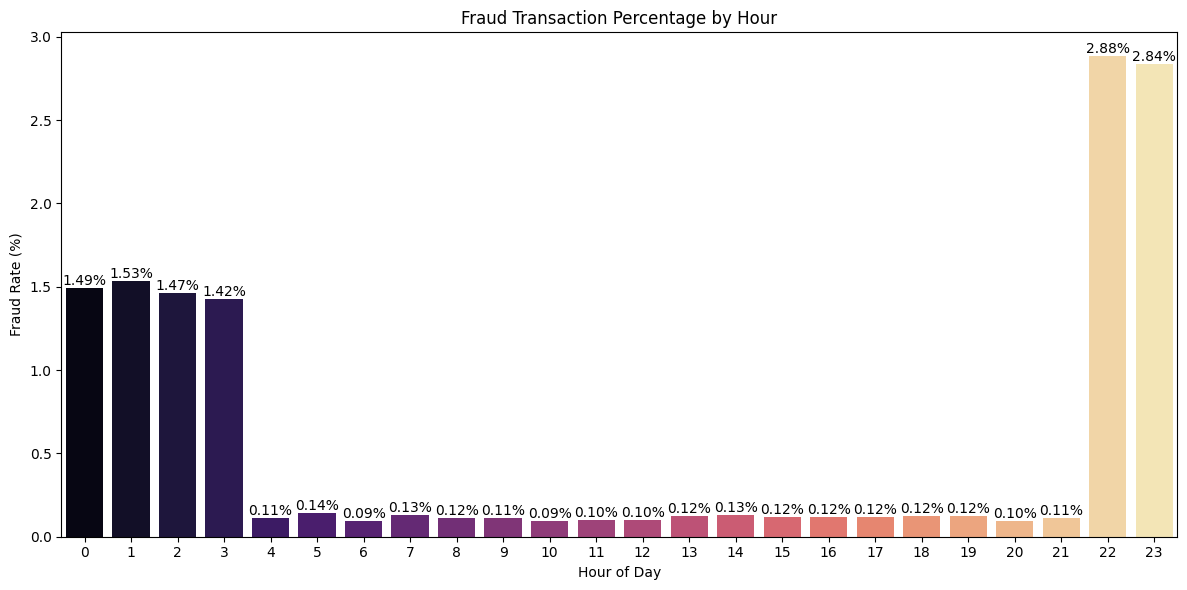

In [16]:
df['hour'] = df['trans_date_trans_time'].dt.hour
hourly_total = df.groupby('hour').size()
hourly_fraud = df[df['is_fraud'] == 1].groupby('hour').size()

hourly_percent = (hourly_fraud / hourly_total * 100).reindex(range(24), fill_value=0)

plt.figure(figsize=(12,6))

sns.barplot(
    x=hourly_percent.index,
    y=hourly_percent.values,
    palette='magma'
)

plt.title('Fraud Transaction Percentage by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')

for i, v in enumerate(hourly_percent.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

##**Sau 10h tối đến 3h sáng dễ bị fraud hơn**

/tmp/ipykernel_57/3915954724.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


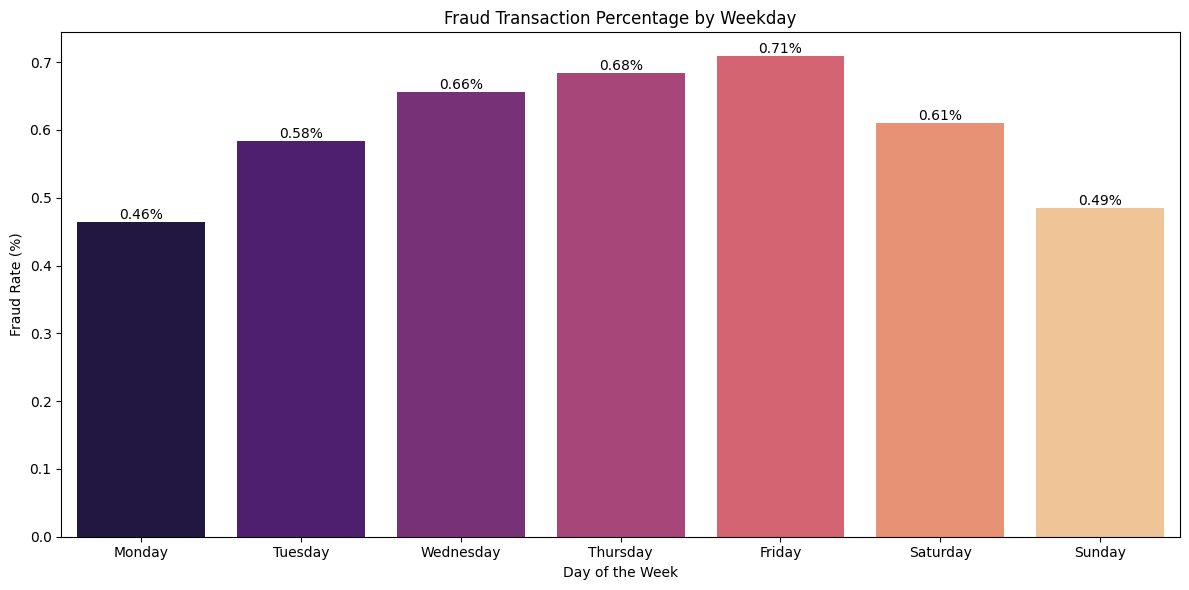

In [17]:
df['weekday'] = df['trans_date_trans_time'].dt.weekday
weekday_total = df.groupby('weekday').size()
weekday_fraud = df[df['is_fraud'] == 1].groupby('weekday').size()
weekday_percent = (weekday_fraud / weekday_total * 100).reindex(range(7), fill_value=0)

days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(12,6))

sns.barplot(
    x=weekday_percent.index,
    y=weekday_percent.values,
    palette='magma'
)

plt.title('Fraud Transaction Percentage by Weekday')
plt.xlabel('Day of the Week')
plt.ylabel('Fraud Rate (%)')

plt.xticks(ticks=range(7), labels=days)

for i, v in enumerate(weekday_percent.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

##**Giữa tuần có tỷ lệ fraud cao hơn**

In [18]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,unix_time,merch_lat,merch_long,is_fraud,month,season,year,year_season,hour,weekday
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1325376018,36.011293,-82.048315,0,2019-01,1,2019,2019 - Winter,0,1
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1325376044,49.159047,-118.186462,0,2019-01,1,2019,2019 - Winter,0,1
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1325376051,43.150704,-112.154481,0,2019-01,1,2019,2019 - Winter,0,1
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1325376076,47.034331,-112.561071,0,2019-01,1,2019,2019 - Winter,0,1
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,1325376186,38.674999,-78.632459,0,2019-01,1,2019,2019 - Winter,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,1371816728,36.841266,-111.690765,0,2020-06,3,2020,2020 - Summer,12,6
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,1371816739,38.906881,-78.246528,0,2020-06,3,2020,2020 - Summer,12,6
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,1371816752,33.619513,-105.130529,0,2020-06,3,2020,2020 - Summer,12,6
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,1371816816,42.788940,-103.241160,0,2020-06,3,2020,2020 - Summer,12,6


In [19]:
df.drop(columns=['month', 'season', 'year', 'year_season', 'hour', 'weekday'],
        inplace=True)

In [20]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
dt = df['trans_date_trans_time'].dt

df['trans_year']    = dt.year
df['trans_month']   = dt.month
df['trans_day']     = dt.day
df['trans_weekday'] = dt.weekday
df['trans_hour']    = dt.hour
df['trans_minute']  = dt.minute
df['trans_second']  = dt.second

# 1=Winter, 2=Spring, 3=Summer, 4=Autumn
df['trans_season'] = ((df['trans_month'] % 12) // 3) + 1

df.drop(columns=['trans_date_trans_time'], inplace=True)

In [21]:
df

,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,merch_long,is_fraud,trans_year,trans_month,trans_day,trans_weekday,trans_hour,trans_minute,trans_second,trans_season
0,0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-82.048315,0,2019,1,1,1,0,0,18,1
1,1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.186462,0,2019,1,1,1,0,0,44,1
2,2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.154481,0,2019,1,1,1,0,0,51,1
3,3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,-112.561071,0,2019,1,1,1,0,1,16,1
4,4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,-78.632459,0,2019,1,1,1,0,3,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,-111.690765,0,2020,6,21,6,12,12,8,3
1296671,1296671,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,-78.246528,0,2020,6,21,6,12,12,19,3
1296672,1296672,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,-105.130529,0,2020,6,21,6,12,12,32,3
1296673,1296673,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,-103.241160,0,2020,6,21,6,12,13,36,3


##**Dữ liệu địa lý**

In [22]:
state_fraud_percentage_all = (
    df.groupby('state')['is_fraud']
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(f"Fraud percentage for Delaware (DE): {state_fraud_percentage_all.get('DE', 0):.2f}%")

Fraud percentage for Delaware (DE): 100.00%


/tmp/ipykernel_57/3611086969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


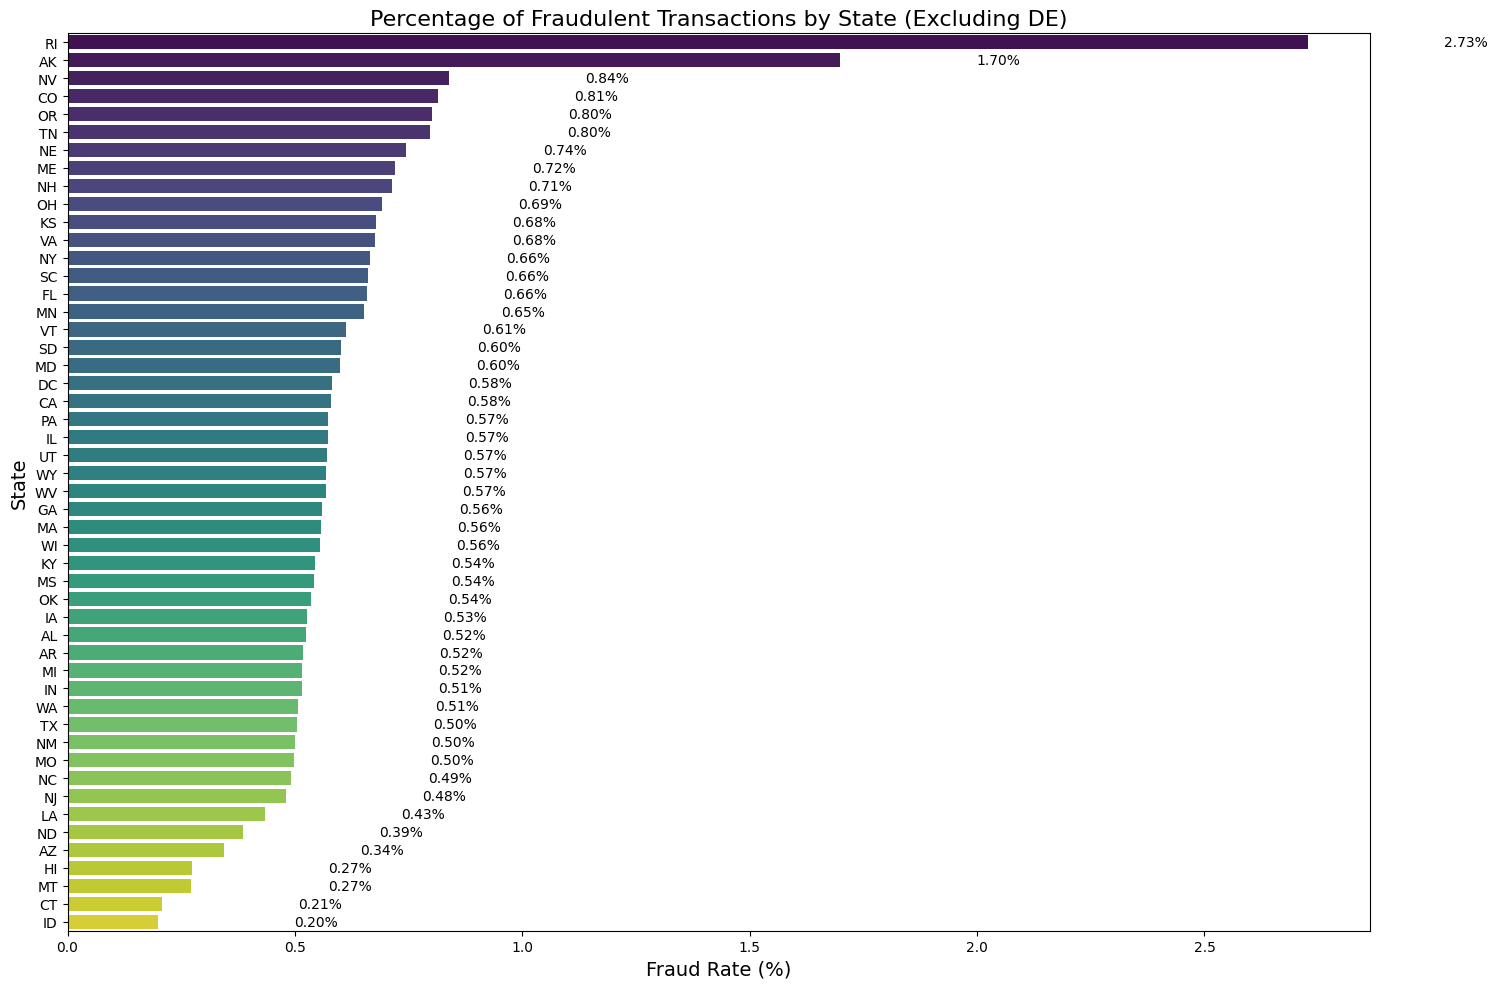

In [23]:
state_fraud_percentage = (
    df.loc[df['state'] != 'DE']
      .groupby('state')['is_fraud']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(15,10))

sns.barplot(
    x=state_fraud_percentage.values,
    y=state_fraud_percentage.index,
    palette='viridis'
)

plt.title('Percentage of Fraudulent Transactions by State (Excluding DE)', fontsize=16)
plt.xlabel('Fraud Rate (%)', fontsize=14)
plt.ylabel('State', fontsize=14)

for i, v in enumerate(state_fraud_percentage.values):
    plt.text(v + 0.3, i, f"{v:.2f}%", va='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_57/3052735486.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('city_pop_bin')['is_fraud']
/tmp/ipykernel_57/3052735486.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


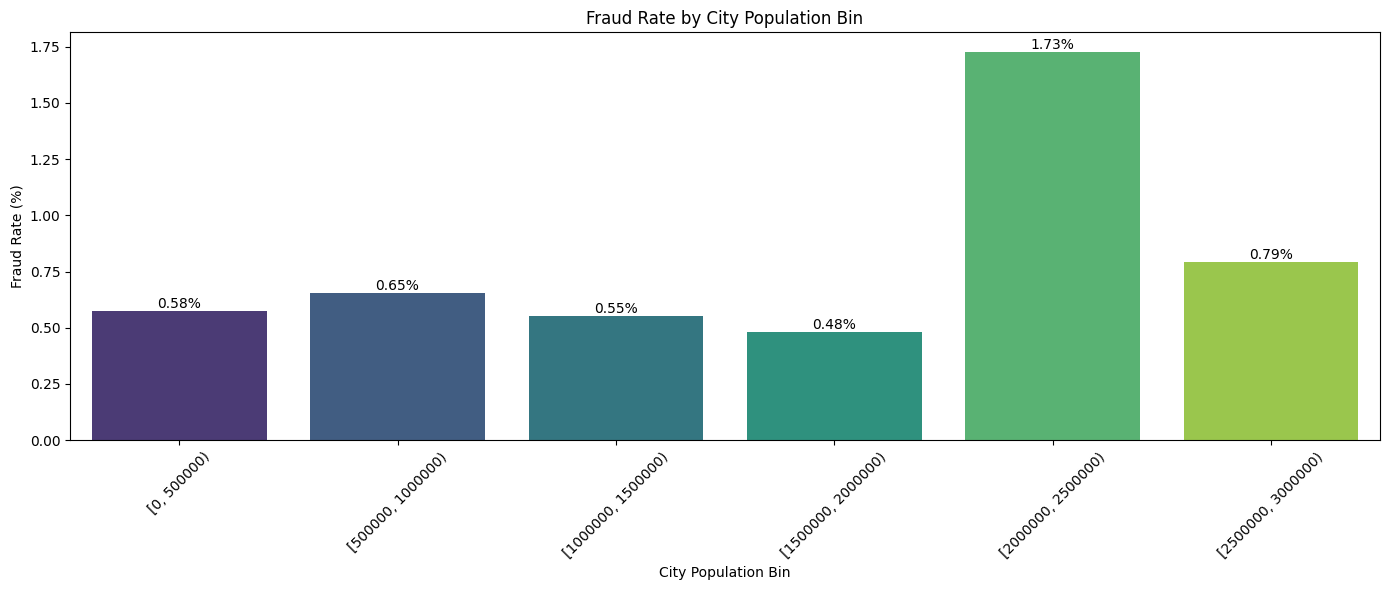

In [24]:
city_pop_bins = list(range(0, 3000001, 500000))

df['city_pop_bin'] = pd.cut(
    df['city_pop'],
    bins=city_pop_bins,
    right=False
)

# Tính fraud rate trực tiếp bằng mean
fraud_rate_by_city_pop = (
    df.groupby('city_pop_bin')['is_fraud']
      .mean()
      .mul(100)
      .reindex(pd.IntervalIndex.from_breaks(city_pop_bins, closed='left'))
)

# Vẽ biểu đồ
plt.figure(figsize=(14,6))

sns.barplot(
    x=fraud_rate_by_city_pop.index.astype(str),
    y=fraud_rate_by_city_pop.values,
    palette='viridis'
)

plt.title('Fraud Rate by City Population Bin')
plt.xlabel('City Population Bin')
plt.ylabel('Fraud Rate (%)')

for i, v in enumerate(fraud_rate_by_city_pop.values):
    if not pd.isna(v):
        plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**Các thành phố từ 2tr đến 2tr5 dân có tỷ lệ fraud cao**

In [25]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # bán kính Trái Đất (km)

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance'] = haversine(
    df['lat'],
    df['long'],
    df['merch_lat'],
    df['merch_long']
)

/tmp/ipykernel_57/526907188.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('distance_bin')['is_fraud']
/tmp/ipykernel_57/526907188.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


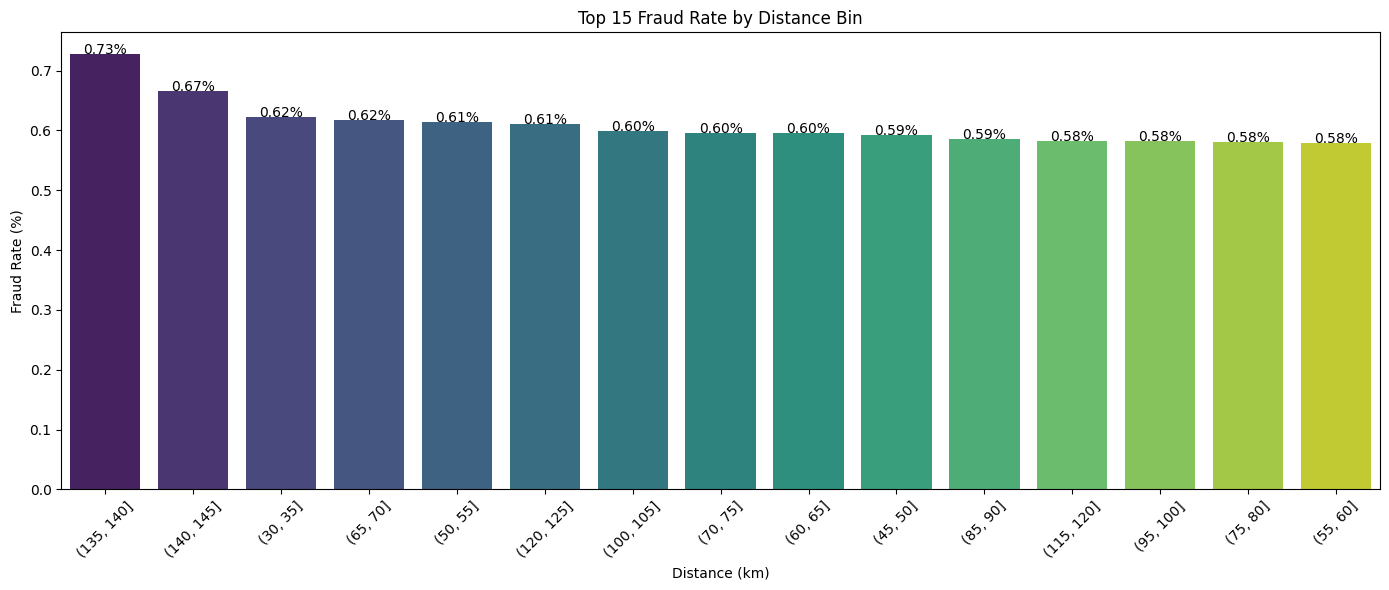

In [26]:
distance_bins = range(0, 170, 5)

df['distance_bin'] = pd.cut(df['distance'], bins=distance_bins)

fraud_rate_by_distance = (
    df.groupby('distance_bin')['is_fraud']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

top_15 = fraud_rate_by_distance.head(15)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_15.index.astype(str),
    y=top_15.values,
    palette='viridis'
)

plt.title('Top 15 Fraud Rate by Distance Bin')
plt.xlabel('Distance (km)')
plt.ylabel('Fraud Rate (%)')

for i, v in enumerate(top_15.values):
    if not pd.isna(v):
        plt.text(i, v, f'{v:.2f}%', ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**Khoảng cách không có nhiều tương quan với tỷ lệ fraud**

##**Dữ liệu hành vi**

/tmp/ipykernel_57/3421561998.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amt_bin')['is_fraud']
/tmp/ipykernel_57/3421561998.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


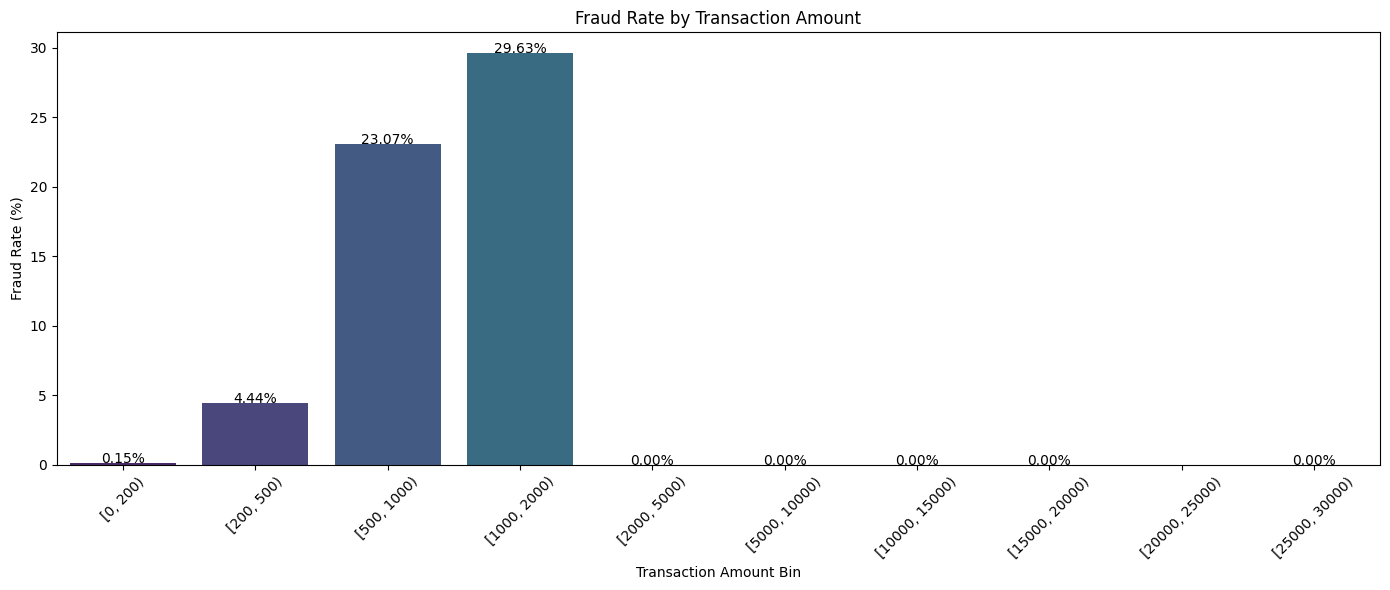

In [27]:
amt_bins = [0, 200, 500, 1000, 2000, 5000, 10000, 15000, 20000, 25000, 30000]

df['amt_bin'] = pd.cut(
    df['amt'],
    bins=amt_bins,
    right=False
)

fraud_rate_by_amt = (
    df.groupby('amt_bin')['is_fraud']
      .mean()
      .mul(100)
      .reindex(pd.IntervalIndex.from_breaks(amt_bins, closed='left'))
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=fraud_rate_by_amt.index.astype(str),
    y=fraud_rate_by_amt.values,
    palette='viridis'
)

plt.title('Fraud Rate by Transaction Amount')
plt.xlabel('Transaction Amount Bin')
plt.ylabel('Fraud Rate (%)')

for i, v in enumerate(fraud_rate_by_amt.values):
    if not pd.isna(v):
        plt.text(i, v, f'{v:.2f}%', ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**200-2000usd có tỷ lệ fraud cao**

/tmp/ipykernel_57/776284014.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


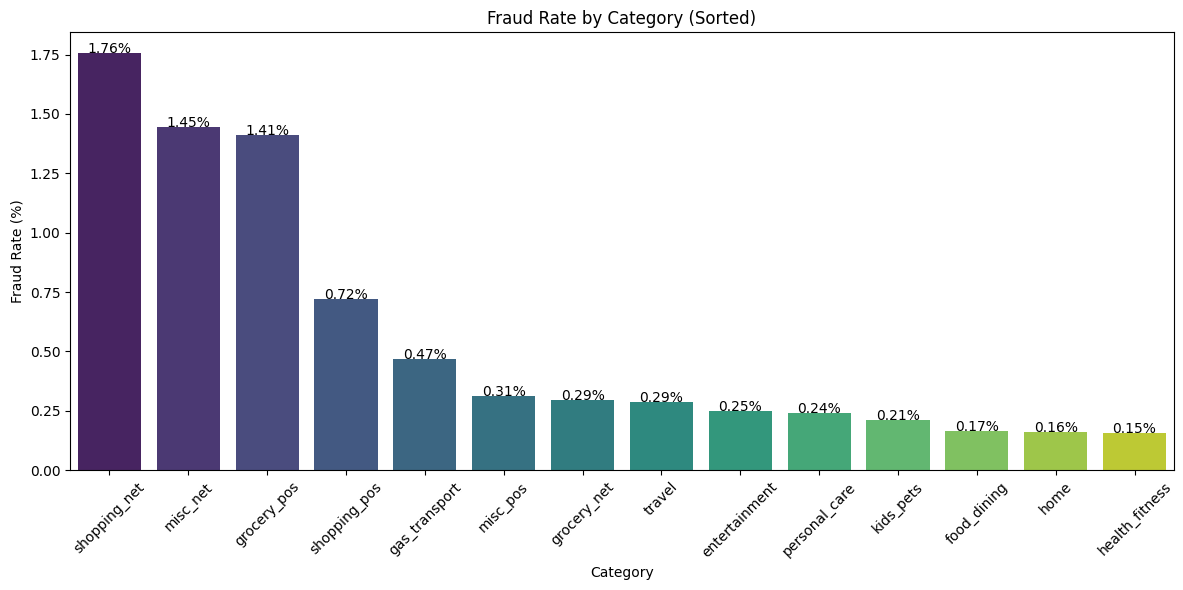

In [28]:
category_fraud_rate = (
    df.groupby('category')['is_fraud']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_fraud_rate.index,
    y=category_fraud_rate.values,
    palette='viridis'
)

plt.title('Fraud Rate by Category (Sorted)')
plt.xlabel('Category')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

for i, v in enumerate(category_fraud_rate.values):
    plt.text(i, v, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

##**Giao dịch online (net) có tỷ lệ gian lận cao nhất**

/tmp/ipykernel_57/347350174.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_fraud_percentage.index, y=gender_fraud_percentage.values, palette='viridis')


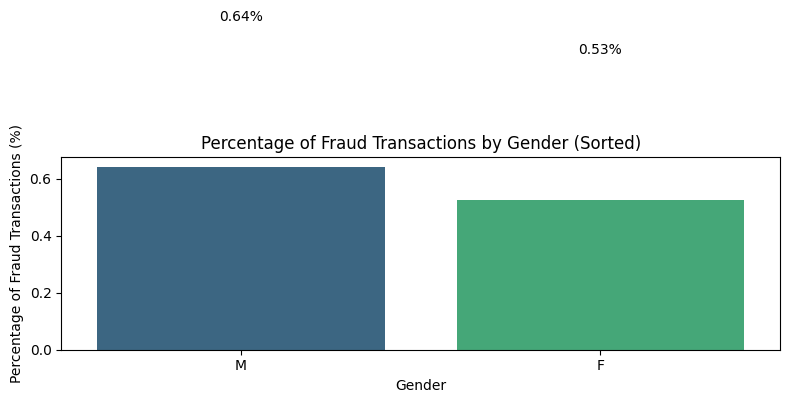

In [29]:
gender_group_total = df.groupby('gender').size()
gender_group_fraud = df[df['is_fraud'] == 1].groupby('gender').size()

gender_fraud_percentage = (gender_group_fraud / gender_group_total) * 100

gender_fraud_percentage = gender_fraud_percentage.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=gender_fraud_percentage.index, y=gender_fraud_percentage.values, palette='viridis')
plt.title('Percentage of Fraud Transactions by Gender (Sorted)')
plt.xlabel('Gender')
plt.ylabel('Percentage of Fraud Transactions (%)')

for i, percentage in enumerate(gender_fraud_percentage.values):
    plt.text(i, percentage + 0.5, f"{percentage:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

##**Tỷ lệ fraud của Nam nhiều hơn Nữ**

In [30]:
fraud_merchants = df['merchant'].str.startswith('fraud', na=False).sum()

non_fraud_merchants = len(df) - fraud_merchants

print(f"Rows where 'merchant' starts with 'fraud': {fraud_merchants}")
print(f"Rows where 'merchant' does not start with 'fraud': {non_fraud_merchants}")

Rows where 'merchant' starts with 'fraud': 1296675
Rows where 'merchant' does not start with 'fraud': 0


In [31]:
def remove_fraud(merchant_name):
    return ''.join(merchant_name.split('_')[1:])
df['merchant'] = df['merchant'].apply(lambda x: remove_fraud(x))
df['merchant'].head()

0            Rippin, Kub and Mann
1       Heller, Gutmann and Zieme
2                  Lind-Buckridge
3    Kutch, Hermiston and Farrell
4                   Keeling-Crist
Name: merchant, dtype: object

/tmp/ipykernel_57/3074440452.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_merchant_fraud_percentage.index, y=top_20_merchant_fraud_percentage.values, palette='viridis')


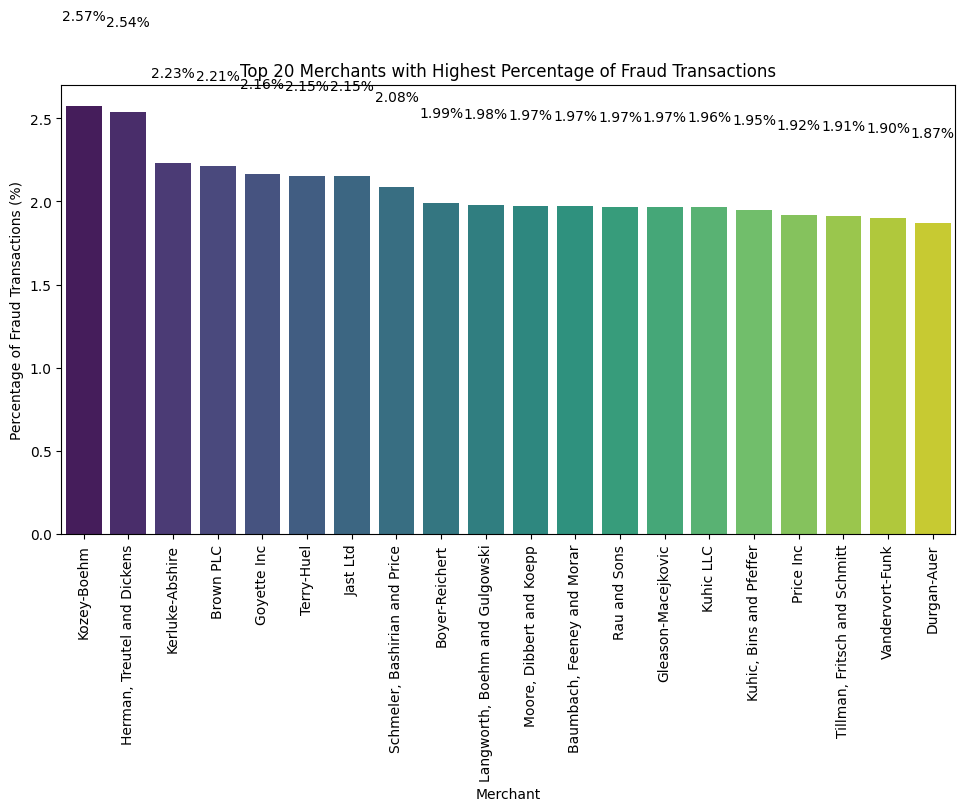

In [32]:
merchant_group_total = df.groupby('merchant').size()
merchant_group_fraud = df[df['is_fraud'] == 1].groupby('merchant').size()

merchant_fraud_percentage = (merchant_group_fraud / merchant_group_total) * 100

top_20_merchant_fraud_percentage = merchant_fraud_percentage.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_20_merchant_fraud_percentage.index, y=top_20_merchant_fraud_percentage.values, palette='viridis')
plt.title('Top 20 Merchants with Highest Percentage of Fraud Transactions')
plt.xlabel('Merchant')
plt.ylabel('Percentage of Fraud Transactions (%)')

for i, percentage in enumerate(top_20_merchant_fraud_percentage.values):
    plt.text(i, percentage + 0.5, f"{percentage:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [33]:
df['dob'] = pd.to_datetime(df['dob'])
df['birth_year'] = df['dob'].dt.year
df['card_holder_age'] = df['trans_year'] - df['birth_year']
df = df.drop(columns=['dob', 'birth_year'])

/tmp/ipykernel_57/3434282197.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_percentage_by_bin.index.astype(str), y=fraud_percentage_by_bin.values, palette='viridis')


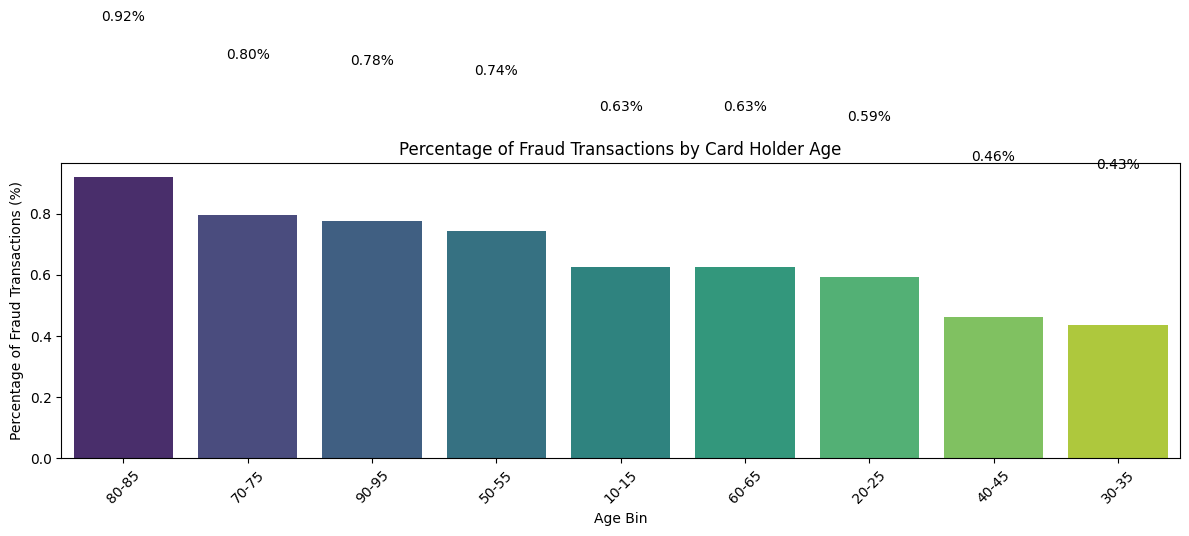

In [34]:
age_bins = range(10, 105, 10)
age_labels = [f"{i}-{i+5}" for i in age_bins[:-1]]

total_transactions_by_bin = pd.cut(df['card_holder_age'], bins=age_bins, labels=age_labels, right=False).value_counts().sort_index()
fraud_transactions_by_bin = pd.cut(df[df['is_fraud'] == 1]['card_holder_age'], bins=age_bins, labels=age_labels, right=False).value_counts().sort_index()

fraud_percentage_by_bin = (fraud_transactions_by_bin / total_transactions_by_bin) * 100
fraud_percentage_by_bin = fraud_percentage_by_bin.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_percentage_by_bin.index.astype(str), y=fraud_percentage_by_bin.values, palette='viridis')
plt.title('Percentage of Fraud Transactions by Card Holder Age')
plt.xlabel('Age Bin')
plt.ylabel('Percentage of Fraud Transactions (%)')

for i, percentage in enumerate(fraud_percentage_by_bin.values):
    if not pd.isna(percentage):
        plt.text(i, percentage + 0.5, f"{percentage:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

##**Nhóm tuổi trên 50 có tỷ lệ fraud cao hơn**

/tmp/ipykernel_57/3150802456.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_percentage_by_job_sorted.index, y=fraud_percentage_by_job_sorted.values, palette='viridis')


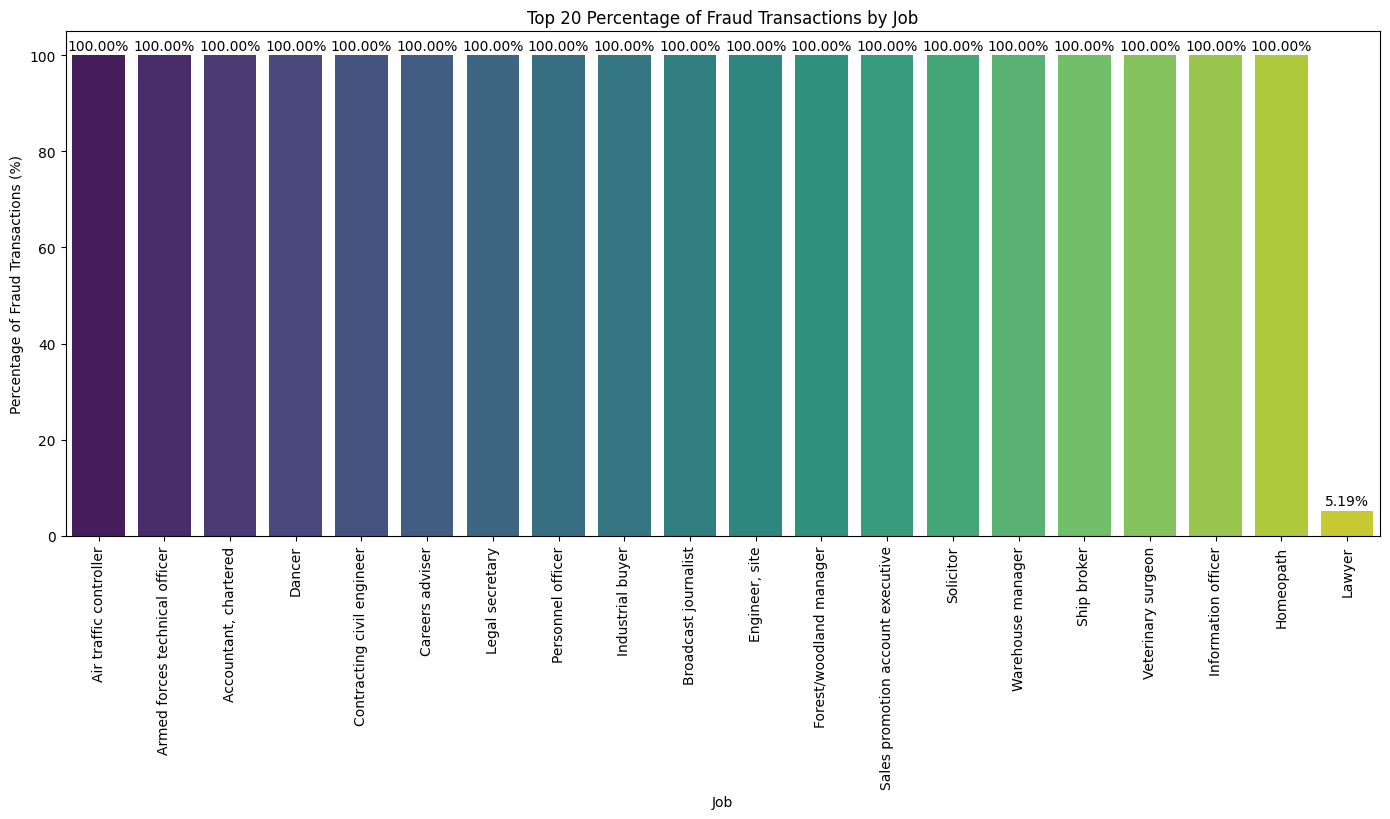

In [35]:
total_transactions_by_job = df['job'].value_counts()
fraud_transactions_by_job = df[df['is_fraud'] == 1]['job'].value_counts()

fraud_percentage_by_job = (fraud_transactions_by_job / total_transactions_by_job) * 100

fraud_percentage_by_job_sorted = fraud_percentage_by_job.sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=fraud_percentage_by_job_sorted.index, y=fraud_percentage_by_job_sorted.values, palette='viridis')
plt.title('Top 20 Percentage of Fraud Transactions by Job')
plt.xlabel('Job')
plt.ylabel('Percentage of Fraud Transactions (%)')

for i, percentage in enumerate(fraud_percentage_by_job_sorted.values):
    if not pd.isna(percentage):
        plt.text(i, percentage + 0.5, f"{percentage:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [36]:
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, recall_score, precision_score, f1_score
import joblib

In [37]:
columns_to_drop = ['Unnamed: 0','first', 'last', 'street', 'city', 'zip', 'trans_num', 'cc_num']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['merchant', 'category', 'amt', 'gender', 'state', 'lat', 'long',
       'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'trans_year', 'trans_month', 'trans_day', 'trans_weekday', 'trans_hour',
       'trans_minute', 'trans_second', 'trans_season', 'city_pop_bin',
       'distance', 'distance_bin', 'amt_bin', 'card_holder_age'],
      dtype='object')

In [38]:
columns_to_drop = ['distance_bin', 'amt_bin','city_pop_bin']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['merchant', 'category', 'amt', 'gender', 'state', 'lat', 'long',
       'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'trans_year', 'trans_month', 'trans_day', 'trans_weekday', 'trans_hour',
       'trans_minute', 'trans_second', 'trans_season', 'distance',
       'card_holder_age'],
      dtype='object')

In [39]:
data_types = pd.DataFrame(df.dtypes).reset_index()
data_types.columns = ['Feature Name', 'Data Type']
data_types

,Feature Name,Data Type
0,merchant,object
1,category,object
2,amt,float64
3,gender,object
4,state,object
5,lat,float64
6,long,float64
7,city_pop,int64
8,job,object
9,unix_time,int64


In [40]:
from sklearn.preprocessing import LabelEncoder
def encode_categorical_columns(df, columns):
    le = LabelEncoder()
    for col in columns:
        df[col] = le.fit_transform(df[col])
    return df

cat_features = ['category', 'gender', 'state','merchant','job']
df = encode_categorical_columns(df, cat_features)
df.head()

,merchant,category,amt,gender,state,lat,long,city_pop,job,unix_time,...,trans_year,trans_month,trans_day,trans_weekday,trans_hour,trans_minute,trans_second,trans_season,distance,card_holder_age
0,514,8,4.97,0,27,36.0788,-81.1781,3495,370,1325376018,...,2019,1,1,1,0,0,18,1,78.597568,31
1,241,4,107.23,0,47,48.8878,-118.2105,149,428,1325376044,...,2019,1,1,1,0,0,44,1,30.212176,41
2,390,0,220.11,1,13,42.1808,-112.2620,4154,307,1325376051,...,2019,1,1,1,0,0,51,1,108.206083,57
3,360,2,45.00,1,26,46.2306,-112.1138,1939,328,1325376076,...,2019,1,1,1,0,1,16,1,95.673231,52
4,297,9,41.96,1,45,38.4207,-79.4629,99,116,1325376186,...,2019,1,1,1,0,3,6,1,77.556744,33


In [41]:
corr_matrix = df.corr(numeric_only=True)

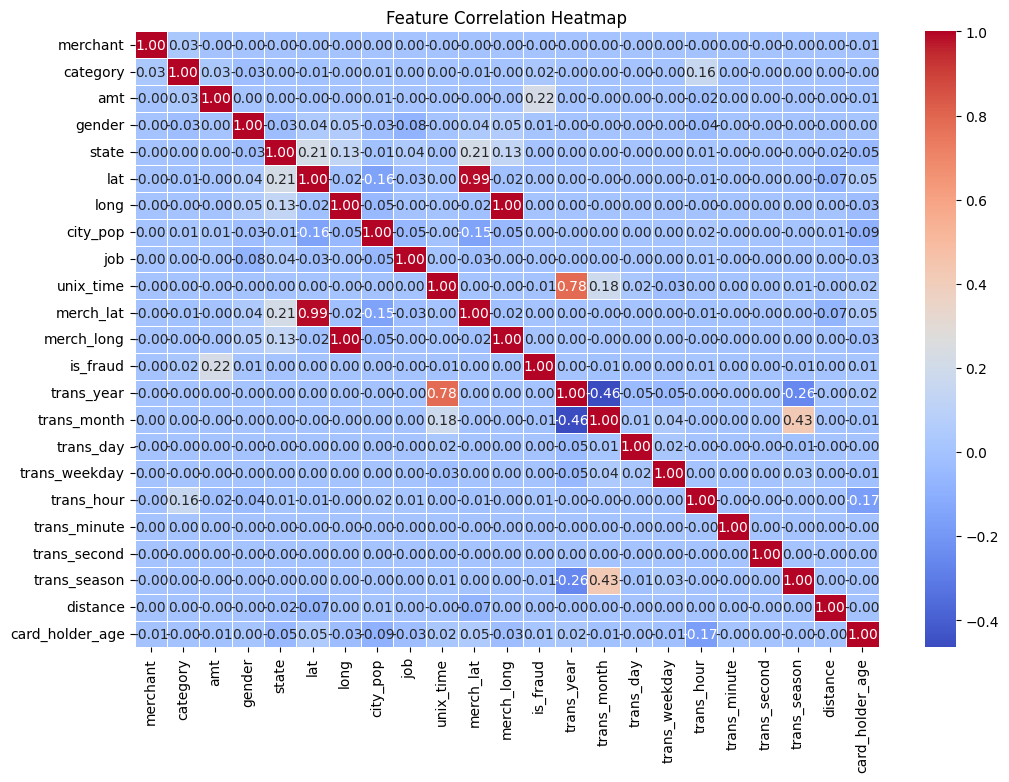

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [43]:
corr_with_fraud = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

print(corr_with_fraud)

is_fraud           1.000000
amt                0.219404
category           0.020205
trans_hour         0.013799
card_holder_age    0.012453
gender             0.007642
trans_day          0.003848
trans_year         0.003004
city_pop           0.002136
lat                0.001894
merch_lat          0.001741
trans_weekday      0.001739
state              0.001730
merch_long         0.001721
long               0.001721
trans_second       0.001095
trans_minute       0.001033
distance           0.000403
job               -0.000093
merchant          -0.000536
unix_time         -0.005078
trans_season      -0.006439
trans_month       -0.012409
Name: is_fraud, dtype: float64


In [ ]:
features = [
    'amt',
    'city_pop',
    'card_holder_age',
    'trans_hour',
    'trans_weekday',
    'trans_month',
    'distance',
    'category',
    'gender',
    'state',
    'merchant',
    'job'
]

X = df[features].copy()
y = df['is_fraud'].copy()

print(f"Features for model: {len(features)}")
print(f"X size: {X.shape}")
print(f"y size: {y.shape}")

Features for model: 12
X size: (1296675, 12)
y size: (1296675,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_normal = X_train[y_train == 0].copy()

print("Train normal:", X_train_normal.shape)
print("Test:", X_test.shape)

Train normal: (1031335, 12)
Test: (259335, 12)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, classification_report, confusion_matrix, precision_score, recall_score

param_grid = {
    "n_estimators": [100, 200],
    "max_samples": [256, 512, 1024],
    "contamination": [0.003, 0.005, 0.008],
    "max_features": [0.7, 1.0],
}

best_f1 = -1
best_params = None
best_threshold = None
best_pipeline = None

for params in ParameterGrid(param_grid):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", IsolationForest(
            n_estimators=params["n_estimators"],
            max_samples=params["max_samples"],
            contamination=params["contamination"],
            max_features=params["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipeline.fit(X_train_normal)

    # score trên train normal
    train_scores = -pipeline.score_samples(X_train_normal)
    threshold = float(np.quantile(train_scores, 1 - params["contamination"]))

    # predict trên test
    test_scores = -pipeline.score_samples(X_test)
    y_pred = (test_scores >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_threshold = threshold
        best_pipeline = pipeline

print("Best params:", best_params)
print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

KeyboardInterrupt: 

In [ ]:
pipeline = best_pipeline
THRESHOLD = best_threshold

test_scores = -pipeline.score_samples(X_test)
y_pred_anomaly = (test_scores >= THRESHOLD).astype(int)

print("Threshold:", THRESHOLD)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_anomaly))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_anomaly, digits=4, zero_division=0))

print("Precision:", precision_score(y_test, y_pred_anomaly, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_anomaly, zero_division=0))
print("F1:", f1_score(y_test, y_pred_anomaly, zero_division=0))

Threshold: 0.5789136460241575

Confusion Matrix:
[[255878   1956]
 [  1125    376]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9956    0.9924    0.9940    257834
           1     0.1612    0.2505    0.1962      1501

    accuracy                         0.9881    259335
   macro avg     0.5784    0.6215    0.5951    259335
weighted avg     0.9908    0.9881    0.9894    259335

Precision: 0.16123499142367068
Recall: 0.2504996668887408
F1: 0.1961909731280981


In [ ]:
import joblib

FEATURES = list(X.columns)

bundle = {
    "pipeline": pipeline,
    "threshold": float(THRESHOLD),
    "features": FEATURES,
}

joblib.dump(bundle, "anomaly_bundle.pkl")

print("Đã lưu: anomaly_bundle.pkl")
print("Features:", FEATURES)
print("Threshold:", THRESHOLD)

Đã lưu: anomaly_bundle.pkl
Features: ['amt', 'city_pop', 'card_holder_age', 'trans_hour', 'trans_weekday', 'trans_month', 'distance', 'category', 'gender', 'state', 'merchant', 'job']
Threshold: 0.5789136460241575


In [ ]:
df["anomaly_score"] = -pipeline.score_samples(X)
df["anomaly"] = (df["anomaly_score"] >= THRESHOLD).astype(int)

print(df[["anomaly_score", "anomaly"]].head())

anomaly_transactions = df[df["anomaly"] == 1]
print("Số anomaly:", len(anomaly_transactions))

df.to_csv("fraud_anomaly_detection_iforest.csv", index=False)

   anomaly_score  anomaly
0       0.476121        0
1       0.510402        0
2       0.550574        0
3       0.482827        0
4       0.494802        0
Số anomaly: 12178


In [46]:
df_stat = df.copy().sort_values("unix_time").reset_index(drop=True)

for c in ['amt', 'distance']:
    past_mean = df_stat[c].rolling(50, min_periods=10).mean().shift(1)
    past_std  = df_stat[c].rolling(50, min_periods=10).std().shift(1)
    df_stat[f"{c}_z"] = (df_stat[c] - past_mean) / (past_std + 1e-6)

df_stat["ema_amt"] = df_stat["amt"].ewm(span=20, adjust=False).mean().shift(1)
df_stat["ema_diff"] = (df_stat["amt"] - df_stat["ema_amt"]).abs()

In [47]:
n = len(df_stat)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_stat.iloc[:train_end].copy()
val_df   = df_stat.iloc[train_end:val_end].copy()
test_df  = df_stat.iloc[val_end:].copy()

In [49]:
y_val = val_df["is_fraud"].astype(int)

candidate_thresholds = np.quantile(
    val_df["stat_score"],
    np.linspace(0.50, 0.995, 200)
)

best_f1 = -1
best_t = None

for t in np.unique(candidate_thresholds):
    pred_val = (val_df["stat_score"] > t).astype(int)
    f1 = f1_score(y_val, pred_val, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best validation F1:", best_f1)
print("Best threshold:", best_t)

Best validation F1: 0.23558215451577802
Best threshold: 10.412507679979512


In [ ]:
city_mu = train_df["city_pop"].mean()
city_sd = train_df["city_pop"].std() + 1e-6

ema_mu = train_df["ema_diff"].mean()
ema_sd = train_df["ema_diff"].std() + 1e-6

amt_mu = train_df["amt"].mean()
amt_sd = train_df["amt"].std() + 1e-6
dist_mu = train_df["distance"].mean()
dist_sd = train_df["distance"].std() + 1e-6

for part in [train_df, val_df, test_df]:
    part["city_pop_z"] = (part["city_pop"] - city_mu) / city_sd
    part["ema_diff_z"] = (part["ema_diff"] - ema_mu) / ema_sd

    cols = ["amt_z", "distance_z", "city_pop_z", "ema_diff_z"]
    part[cols] = part[cols].replace([np.inf, -np.inf], np.nan).fillna(0)

for part in [train_df, val_df, test_df]:
    part["stat_score"] = (
        part["amt_z"].abs() +
        part["distance_z"].abs() +
        part["city_pop_z"].abs() +
        part["ema_diff_z"].abs()
    )

SCALER_PARAMS = {
    "city_mu": city_mu,
    "city_sd": city_sd,
    "ema_mu": ema_mu,
    "ema_sd": ema_sd,
    "amt_mu": amt_mu,
    "amt_sd": amt_sd,
    "dist_mu": dist_mu,
    "dist_sd": dist_sd,
}
print("Scaler params:", SCALER_PARAMS)


In [51]:
y_test = test_df["is_fraud"].astype(int)
pred_test = (test_df["stat_score"] > best_t).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, pred_test, digits=4, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0     0.9963    0.9896    0.9929    193369
           1     0.1732    0.3707    0.2361      1133

    accuracy                         0.9860    194502
   macro avg     0.5847    0.6802    0.6145    194502
weighted avg     0.9915    0.9860    0.9885    194502



In [53]:
from itertools import product
feature_cols = ["amt_z", "distance_z", "city_pop_z", "ema_diff_z"]

weight_grid = [0.5, 1.0, 1.5, 2.0, 3.0]

y_val = val_df["is_fraud"].astype(int)

best_f1 = -1
best_t = None
best_weights = None

for w in product(weight_grid, repeat=4):
    w_amt, w_dist, w_city, w_ema = w
    
    val_score = (
        w_amt  * val_df["amt_z"].abs() +
        w_dist * val_df["distance_z"].abs() +
        w_city * val_df["city_pop_z"].abs() +
        w_ema  * val_df["ema_diff_z"].abs()
    )
    
    thresholds = np.quantile(val_score, np.linspace(0.50, 0.995, 150))
    
    for t in np.unique(thresholds):
        pred_val = (val_score > t).astype(int)
        f1 = f1_score(y_val, pred_val, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
            best_weights = w

print("Best validation F1:", best_f1)
print("Best threshold:", best_t)
print("Best weights:", best_weights)

Best validation F1: 0.3782654127481714
Best threshold: 14.269445387769874
Best weights: (0.5, 0.5, 0.5, 3.0)


In [55]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

w_amt, w_dist, w_city, w_ema = best_weights

test_score = (
    w_amt  * test_df["amt_z"].abs() +
    w_dist * test_df["distance_z"].abs() +
    w_city * test_df["city_pop_z"].abs() +
    w_ema  * test_df["ema_diff_z"].abs()
)

pred_test = (test_score > best_t).astype(int)
y_test = test_df["is_fraud"].astype(int)


print("\nClassification Report:")
print(classification_report(y_test, pred_test, digits=4, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0     0.9967    0.9941    0.9954    193369
           1     0.3029    0.4395    0.3587      1133

    accuracy                         0.9908    194502
   macro avg     0.6498    0.7168    0.6770    194502
weighted avg     0.9927    0.9908    0.9917    194502



In [ ]:
import pickle

stat_bundle = {
    "threshold": float(best_t),
    "best_f1": float(best_f1),
    "best_weights": tuple(float(x) for x in best_weights),

    "rolling_window": 50,
    "ema_span": 20,

    "zscore_features": ["amt", "distance"],
    "extra_features": ["city_pop", "ema_diff"],

    "city_mu": SCALER_PARAMS["city_mu"],
    "city_sd": SCALER_PARAMS["city_sd"],
    "ema_mu": SCALER_PARAMS["ema_mu"],
    "ema_sd": SCALER_PARAMS["ema_sd"],
    "amt_mu": SCALER_PARAMS["amt_mu"],
    "amt_sd": SCALER_PARAMS["amt_sd"],
    "dist_mu": SCALER_PARAMS["dist_mu"],
    "dist_sd": SCALER_PARAMS["dist_sd"],
}

with open("statistical_fraud_model.pkl", "wb") as f:
    pickle.dump(stat_bundle, f)

print("Saved successfully!")

Saved successfully!


In [57]:
import pickle

with open("statistical_fraud_model.pkl", "rb") as f:
    loaded_bundle = pickle.load(f)

print(loaded_bundle)

{'threshold': 14.269445387769874, 'best_f1': 0.3782654127481714, 'best_weights': (0.5, 0.5, 0.5, 3.0), 'rolling_window': 50, 'ema_span': 20, 'zscore_features': ['amt', 'distance'], 'extra_features': ['city_pop', 'ema_diff'], 'city_mu': 89119.2017898536, 'city_sd': 302553.8607869619, 'ema_mu': 60.92200222843943, 'ema_sd': 153.9179746304863}
